# ALPA-Net Pretraining on PTB-XL

**ALPA-Net: Anatomical Lead Prior Attention Network**  
*A physiology-guided CNN-Transformer architecture for multi-territory myocardial infarction localization.*

## 1. Imports and CONFIG

In [1]:
import ast
import csv
import json
import logging
import math
import os
import random
import re
import time
import traceback
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path('..').resolve() if Path.cwd().name == 'notebook' else Path('.').resolve()
RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

CONFIG = {
    'seed': 42,
    'dataset_dir': str(PROJECT_ROOT / 'dataset' / 'ptb_xl'),
    'output_base_dir': str(PROJECT_ROOT / 'outputs' / 'pretrain_alpanet_ptbxl'),
    'run_name': RUN_TIMESTAMP,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    'batch_size': 64,
    'epochs': 50,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'scheduler_patience': 5,
    'early_stopping_enabled': False,
    'early_stopping_patience': 12,
    'threshold': 0.5,
    'tune_thresholds': True,
    'lambda_alpa': 0.2,
    'lambda_territory': 0.3,
    'lambda_exclusive': 0.1,
    'lambda_consistency': 0.1,
    'model': {
        'input_leads': 12,
        'signal_length': 1000,
        'stem_channels': 32,
        'cnn_channels': 64,
        'token_dim': 128,
        'num_heads': 4,
        'cross_lead_layers': 2,
        'temporal_layers': 1,
        'transformer_ff_dim': 256,
        'dropout': 0.20,
        'temporal_segments': 20,
        'main_outputs': 4,
        'territory_outputs': 3,
    },
}

MAIN_LABELS = ['Normal', 'Anterior', 'Inferior', 'Lateral']
TERRITORY_LABELS = ['Anterior', 'Inferior', 'Lateral']
LEAD_ORDER = ['I', 'aVL', 'II', 'III', 'aVF', 'aVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_PRIOR_CONFIG = {
    'lead_order': LEAD_ORDER,
    'normal': 'uniform over 12 leads',
    'territories': {
        'Anterior': ['V1', 'V2', 'V3', 'V4'],
        'Inferior': ['II', 'III', 'aVF'],
        'Lateral': ['I', 'aVL', 'V5', 'V6'],
    },
}
LABEL_MAPPING = {
    'main_label_order': MAIN_LABELS,
    'territory_order': TERRITORY_LABELS,
    'normal': [1, 0, 0, 0],
    'anterior': [0, 1, 0, 0],
    'inferior': [0, 0, 1, 0],
    'lateral': [0, 0, 0, 1],
    'multi_label': True,
    'recommended_main_loss': 'BCEWithLogitsLoss',
}

print('Device:', CONFIG['device'])
print('Dataset:', CONFIG['dataset_dir'])
print('Run:', CONFIG['run_name'])

Device: cuda
Dataset: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/dataset/ptb_xl
Run: 20260607_190207


## 2. Output directory and logging setup

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CONFIG['seed'])

OUTPUT_DIR = Path(CONFIG['output_base_dir']) / CONFIG['run_name']
CONFIG_DIR = OUTPUT_DIR / 'configs'
LOG_DIR = OUTPUT_DIR / 'logs'
CKPT_DIR = OUTPUT_DIR / 'checkpoints'
PLOT_DIR = OUTPUT_DIR / 'plots'
PRED_DIR = OUTPUT_DIR / 'predictions'
TRANSFER_DIR = OUTPUT_DIR / 'transfer_ready'
for directory in [CONFIG_DIR, LOG_DIR, CKPT_DIR, PLOT_DIR, PRED_DIR, TRANSFER_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

with open(CONFIG_DIR / 'config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)

logger = logging.getLogger('pretrain_alpanet')
logger.setLevel(logging.INFO)
logger.handlers.clear()
formatter = logging.Formatter('%(asctime)s | %(levelname)s | %(message)s')
stream_handler = logging.StreamHandler()
stream_handler.setFormatter(formatter)
file_handler = logging.FileHandler(LOG_DIR / 'train.log')
file_handler.setFormatter(formatter)
ROOT_OUTPUT_LOG = PROJECT_ROOT / 'output.log'
root_file_handler = logging.FileHandler(ROOT_OUTPUT_LOG)
root_file_handler.setFormatter(formatter)
error_handler = logging.FileHandler(LOG_DIR / 'error.log')
error_handler.setLevel(logging.ERROR)
error_handler.setFormatter(formatter)
logger.addHandler(stream_handler)
logger.addHandler(file_handler)
logger.addHandler(root_file_handler)
logger.addHandler(error_handler)

logger.info('Output directory: %s', OUTPUT_DIR)
logger.info('Root output log: %s', ROOT_OUTPUT_LOG)
logger.info('Device: %s', CONFIG['device'])

2026-06-07 19:02:07,544 | INFO | Output directory: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207


2026-06-07 19:02:07,545 | INFO | Root output log: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/output.log


2026-06-07 19:02:07,545 | INFO | Device: cuda


## 3. Data loading

In [3]:
def load_split(dataset_dir, split):
    split_dir = Path(dataset_dir) / split
    x = np.load(split_dir / 'x.npy').astype(np.float32)
    y_main = np.load(split_dir / 'main_label.npy').astype(np.float32)
    y_territory = np.load(split_dir / 'territory.npy').astype(np.float32)
    lead_prior = np.load(split_dir / 'lead_prior.npy').astype(np.float32)
    labels_df = pd.read_csv(split_dir / 'labels.csv')
    metadata_df = pd.read_csv(split_dir / 'metadata.csv')
    return x, y_main, y_territory, lead_prior, labels_df, metadata_df

DATASET_DIR = Path(CONFIG['dataset_dir'])
x_train, y_train, territory_train, prior_train, labels_train, meta_train = load_split(DATASET_DIR, 'train')
x_val, y_val, territory_val, prior_val, labels_val, meta_val = load_split(DATASET_DIR, 'val')
x_test, y_test, territory_test, prior_test, labels_test, meta_test = load_split(DATASET_DIR, 'test')

lead_order_file = DATASET_DIR / 'lead_order.csv'
if lead_order_file.exists():
    dataset_leads = pd.read_csv(lead_order_file)['lead'].tolist()
    if dataset_leads != LEAD_ORDER:
        raise ValueError(f'Lead order mismatch. Expected {LEAD_ORDER}, got {dataset_leads}')

logger.info('Train shape: %s | Val shape: %s | Test shape: %s', x_train.shape, x_val.shape, x_test.shape)
display(pd.read_csv(DATASET_DIR / 'split_summary.csv'))

2026-06-07 19:02:07,715 | INFO | Train shape: (11986, 1000, 12) | Val shape: (1500, 1000, 12) | Test shape: (1516, 1000, 12)


,split,records,Normal,Anterior,Inferior,Lateral
0,train,11986,7606,2469,2623,953
1,val,1500,957,307,330,121
2,test,1516,964,308,328,119


## 4. Label mapping and lead prior generation

In [4]:
def normalize_label_text(value):
    if value is None or pd.isna(value):
        return ''
    text = str(value).strip().lower()
    text = text.replace('_', '-').replace('/', '-').replace(',', ' ')
    text = re.sub(r'\([^)]*\)', ' ', text)
    text = re.sub(r'[^a-z0-9\- ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    aliases = {
        'anteroseptal': 'antero-septal',
        'anterolateral': 'antero-lateral',
        'inferolateral': 'infero-lateral',
        'inferoposterior': 'infero-posterior',
        'inferoposterolateral': 'infero-postero-lateral',
        'posterolateral': 'postero-lateral',
    }
    for src, dst in aliases.items():
        text = text.replace(src, dst)
    return text

def build_territory_vector(label_text):
    texts = label_text if isinstance(label_text, (list, tuple, set)) else [label_text]
    territories = set()
    for value in texts:
        text = normalize_label_text(value)
        if not text or text in {'normal', 'no', 'unknown', 'nan'}:
            continue
        if 'antero-lateral' in text:
            territories.update(['Anterior', 'Lateral'])
        elif 'anterior' in text or 'antero' in text:
            territories.add('Anterior')
        if 'infero-postero-lateral' in text or 'infero-poster-lateral' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'infero-lateral' in text or 'infero-latera' in text:
            territories.update(['Inferior', 'Lateral'])
        elif 'inferior' in text or 'infero' in text:
            territories.add('Inferior')
        if 'postero-lateral' in text or 'lateral' in text:
            territories.add('Lateral')
    return np.array([1 if label in territories else 0 for label in TERRITORY_LABELS], dtype=np.float32)

def build_lead_prior_vector(territory_vector):
    territory_vector = np.asarray(territory_vector, dtype=np.float32)
    active = [name for name, flag in zip(TERRITORY_LABELS, territory_vector) if flag > 0]
    if not active:
        return np.ones(len(LEAD_ORDER), dtype=np.float32) / len(LEAD_ORDER)
    weights = np.zeros(len(LEAD_ORDER), dtype=np.float32)
    active_leads = set()
    for territory in active:
        active_leads.update(LEAD_PRIOR_CONFIG['territories'][territory])
    for lead in active_leads:
        weights[LEAD_ORDER.index(lead)] = 1.0
    return weights / weights.sum()

def build_main_label_vector(sub_label):
    territory = build_territory_vector(sub_label)
    if normalize_label_text(sub_label) == 'normal' and territory.sum() == 0:
        return np.array([1, 0, 0, 0], dtype=np.float32)
    return np.concatenate([[0], territory]).astype(np.float32)

def _parse_json_vector(value, dtype=np.float32):
    if isinstance(value, str):
        return np.array(json.loads(value), dtype=dtype)
    return np.array(value, dtype=dtype)

def validate_label_mapping(labels_df, y_main, y_territory, lead_prior, dataset_name):
    if y_main.shape[1] != 4:
        raise ValueError(f'{dataset_name}: main_label_vector must have 4 outputs')
    if y_territory.shape[1] != 3:
        raise ValueError(f'{dataset_name}: territory_vector must have 3 outputs')
    if lead_prior.shape[1] != 12:
        raise ValueError(f'{dataset_name}: lead_prior_vector must have 12 outputs')
    if not np.allclose(lead_prior.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f'{dataset_name}: lead_prior_vector rows must sum to 1')
    if ((y_main[:, 0] == 1) & (y_main[:, 1:].sum(axis=1) > 0)).any():
        raise ValueError(f'{dataset_name}: Normal active together with MI territory')

    main_counts = pd.Series(y_main.sum(axis=0).astype(int), index=MAIN_LABELS, name='count')
    territory_counts = pd.Series(y_territory.sum(axis=0).astype(int), index=TERRITORY_LABELS, name='count')
    multi = int((y_territory.sum(axis=1) > 1).sum())
    logger.info('%s label distribution: %s', dataset_name, main_counts.to_dict())
    logger.info('%s multi-territory samples: %d', dataset_name, multi)
    display(main_counts.to_frame())
    display(territory_counts.to_frame())
    display(labels_df[['record_id', 'raw_label', 'sub_label', 'main_label_vector', 'territory_vector', 'lead_prior_vector']].head(10))

validate_label_mapping(labels_train, y_train, territory_train, prior_train, 'train')
validate_label_mapping(labels_val, y_val, territory_val, prior_val, 'val')
validate_label_mapping(labels_test, y_test, territory_test, prior_test, 'test')

2026-06-07 19:02:07,726 | INFO | train label distribution: {'Normal': 7606, 'Anterior': 2469, 'Inferior': 2623, 'Lateral': 953}


2026-06-07 19:02:07,727 | INFO | train multi-territory samples: 1442


,count
Normal,7606
Anterior,2469
Inferior,2623
Lateral,953


,count
Anterior,2469
Inferior,2623
Lateral,953


,record_id,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector
0,1,NORM|LVOLT|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
1,2,NORM|SBRAD,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
2,3,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
3,4,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
4,5,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
5,6,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
6,7,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
7,11,NORM|SARRH,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
8,12,NORM|SBRAD,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
9,13,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."


...

2026-06-07 19:02:07,738 | INFO | test label distribution: {'Normal': 964, 'Anterior': 308, 'Inferior': 328, 'Lateral': 119}


2026-06-07 19:02:07,738 | INFO | test multi-territory samples: 172


,count
Normal,964
Anterior,308
Inferior,328
Lateral,119


,count
Anterior,308
Inferior,328
Lateral,119


,record_id,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector
0,9,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
1,38,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
2,40,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
3,57,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
4,59,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
5,63,ASMI|ABQRS|SR,antero-septal,"[0, 1, 0, 0]","[1, 0, 0]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.25, 0.25, 0.2..."
6,75,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
7,76,NORM|SARRH,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
8,79,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."
9,93,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333..."


## 5. Dataset and DataLoader

In [5]:
class PerLeadZScore:
    def __init__(self, eps=1e-6):
        self.eps = eps
        self.mean_ = None
        self.std_ = None

    def fit(self, x):
        self.mean_ = x.mean(axis=(0, 1), keepdims=True)
        self.std_ = x.std(axis=(0, 1), keepdims=True)
        self.std_ = np.maximum(self.std_, self.eps)
        return self

    def transform(self, x):
        return ((x - self.mean_) / self.std_).astype(np.float32)

normalizer = PerLeadZScore().fit(x_train)
x_train_n = normalizer.transform(x_train)
x_val_n = normalizer.transform(x_val)
x_test_n = normalizer.transform(x_test)
np.save(TRANSFER_DIR / 'normalizer_mean.npy', normalizer.mean_.astype(np.float32))
np.save(TRANSFER_DIR / 'normalizer_std.npy', normalizer.std_.astype(np.float32))

class ECGPretrainDataset(Dataset):
    def __init__(self, x, y_main, y_territory, lead_prior, labels_df=None):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y_main = torch.tensor(y_main, dtype=torch.float32)
        self.y_territory = torch.tensor(y_territory, dtype=torch.float32)
        self.lead_prior = torch.tensor(lead_prior, dtype=torch.float32)
        self.labels_df = labels_df.reset_index(drop=True) if labels_df is not None else None

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            'x': self.x[idx],
            'y_main': self.y_main[idx],
            'y_territory': self.y_territory[idx],
            'lead_prior': self.lead_prior[idx],
            'idx': idx,
        }

train_ds = ECGPretrainDataset(x_train_n, y_train, territory_train, prior_train, labels_train)
val_ds = ECGPretrainDataset(x_val_n, y_val, territory_val, prior_val, labels_val)
test_ds = ECGPretrainDataset(x_test_n, y_test, territory_test, prior_test, labels_test)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=CONFIG['num_workers'], pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=torch.cuda.is_available())

logger.info('DataLoaders ready: train=%d val=%d test=%d', len(train_ds), len(val_ds), len(test_ds))

2026-06-07 19:02:08,608 | INFO | DataLoaders ready: train=11986 val=1500 test=1516


## 6. ALPA-Net model definition

In [6]:
class SharedLeadCNNStem(nn.Module):
    def __init__(self, in_channels=1, stem_channels=32, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, stem_channels, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(stem_channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class MultiScaleResidualCNNBlock(nn.Module):
    def __init__(self, channels, kernels=(3, 7, 15, 31), dropout=0.1):
        super().__init__()
        branch_channels = channels // len(kernels)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(channels, branch_channels, kernel_size=k, padding=k // 2, bias=False),
                nn.BatchNorm1d(branch_channels),
                nn.GELU(),
            )
            for k in kernels
        ])
        self.project = nn.Sequential(
            nn.Conv1d(branch_channels * len(kernels), channels, kernel_size=1, bias=False),
            nn.BatchNorm1d(channels),
            nn.Dropout(dropout),
        )
        self.act = nn.GELU()

    def forward(self, x):
        out = torch.cat([branch(x) for branch in self.branches], dim=1)
        out = self.project(out)
        return self.act(out + x)

class LeadTokenBuilder(nn.Module):
    def __init__(self, in_channels, token_dim):
        super().__init__()
        self.proj = nn.Linear(in_channels, token_dim)

    def forward(self, lead_features):
        pooled = lead_features.mean(dim=-1)
        return self.proj(pooled)

class ALPAModule(nn.Module):
    def __init__(self, token_dim, num_classes=4, dropout=0.1):
        super().__init__()
        self.class_queries = nn.Parameter(torch.randn(num_classes, token_dim) * 0.02)
        self.key = nn.Linear(token_dim, token_dim)
        self.value = nn.Linear(token_dim, token_dim)
        self.dropout = nn.Dropout(dropout)
        self.scale = token_dim ** -0.5

    def forward(self, lead_tokens):
        keys = self.key(lead_tokens)
        values = self.value(lead_tokens)
        logits = torch.einsum('ct,blt->bcl', self.class_queries, keys) * self.scale
        attention = torch.softmax(logits, dim=-1)
        context = torch.einsum('bcl,bld->bcd', attention, values)
        context = self.dropout(context)
        return context, attention

class LeadTimeAttentionPooling(nn.Module):
    def __init__(self, token_dim, dropout=0.1):
        super().__init__()
        self.score = nn.Sequential(
            nn.LayerNorm(token_dim),
            nn.Linear(token_dim, token_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_dim // 2, 1),
        )

    def forward(self, tokens):
        scores = self.score(tokens).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.einsum('bn,bnd->bd', weights, tokens)
        return pooled, weights

class ALPANetBackbone(nn.Module):
    def __init__(self, config):
        super().__init__()
        m = config['model']
        self.input_leads = m['input_leads']
        self.temporal_segments = m['temporal_segments']
        self.stem = SharedLeadCNNStem(1, m['stem_channels'], m['dropout'])
        self.channel_project = nn.Sequential(
            nn.Conv1d(m['stem_channels'], m['cnn_channels'], kernel_size=1, bias=False),
            nn.BatchNorm1d(m['cnn_channels']),
            nn.GELU(),
        )
        self.multi_scale = MultiScaleResidualCNNBlock(m['cnn_channels'], dropout=m['dropout'])
        self.token_builder = LeadTokenBuilder(m['cnn_channels'], m['token_dim'])
        self.alpa = ALPAModule(m['token_dim'], num_classes=m['main_outputs'], dropout=m['dropout'])
        cross_layer = nn.TransformerEncoderLayer(
            d_model=m['token_dim'], nhead=m['num_heads'], dim_feedforward=m['transformer_ff_dim'],
            dropout=m['dropout'], batch_first=True, activation='gelu', norm_first=True,
        )
        self.cross_lead_transformer = nn.TransformerEncoder(cross_layer, num_layers=m['cross_lead_layers'])
        temporal_layer = nn.TransformerEncoderLayer(
            d_model=m['token_dim'], nhead=m['num_heads'], dim_feedforward=m['transformer_ff_dim'],
            dropout=m['dropout'], batch_first=True, activation='gelu', norm_first=True,
        )
        self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=m['temporal_layers'])
        self.pooling = LeadTimeAttentionPooling(m['token_dim'], dropout=m['dropout'])
        self.norm = nn.LayerNorm(m['token_dim'] * 2)

    def forward(self, x):
        # x: [B, T, L]
        b, t, l = x.shape
        x_lead = x.permute(0, 2, 1).reshape(b * l, 1, t)
        features = self.stem(x_lead)
        features = self.channel_project(features)
        features = self.multi_scale(features)
        lead_features = features.reshape(b, l, features.shape[1], features.shape[2])
        lead_tokens = self.token_builder(lead_features)
        alpa_context, lead_attention = self.alpa(lead_tokens)
        lead_tokens = self.cross_lead_transformer(lead_tokens + alpa_context.mean(dim=1, keepdim=True))

        segment_features = F.adaptive_avg_pool1d(features, self.temporal_segments)
        segment_features = segment_features.reshape(b, l, segment_features.shape[1], self.temporal_segments).mean(dim=1)
        temporal_tokens = segment_features.permute(0, 2, 1)
        temporal_tokens = self.temporal_transformer(self.token_builder.proj(temporal_tokens))

        lead_pooled, lead_pool_weights = self.pooling(lead_tokens)
        time_pooled, time_pool_weights = self.pooling(temporal_tokens)
        embedding = self.norm(torch.cat([lead_pooled, time_pooled], dim=-1))
        return {
            'embedding': embedding,
            'lead_tokens': lead_tokens,
            'temporal_tokens': temporal_tokens,
            'lead_attention': lead_attention,
            'lead_pool_weights': lead_pool_weights,
            'time_pool_weights': time_pool_weights,
        }

class ALPANet(nn.Module):
    def __init__(self, config):
        super().__init__()
        m = config['model']
        self.backbone = ALPANetBackbone(config)
        head_in = m['token_dim'] * 2
        self.main_head = nn.Sequential(nn.Linear(head_in, m['token_dim']), nn.GELU(), nn.Dropout(m['dropout']), nn.Linear(m['token_dim'], m['main_outputs']))
        self.territory_head = nn.Sequential(nn.Linear(head_in, m['token_dim'] // 2), nn.GELU(), nn.Dropout(m['dropout']), nn.Linear(m['token_dim'] // 2, m['territory_outputs']))

    def forward(self, x):
        features = self.backbone(x)
        main_logits = self.main_head(features['embedding'])
        territory_logits = self.territory_head(features['embedding'])
        return {**features, 'main_logits': main_logits, 'territory_logits': territory_logits}

def freeze_for_transfer(model, scheme):
    for p in model.parameters():
        p.requires_grad = True
    if scheme == 'frozen_backbone':
        for p in model.backbone.parameters():
            p.requires_grad = False
    elif scheme == 'partial_finetune':
        for p in model.backbone.stem.parameters():
            p.requires_grad = False
        for p in model.backbone.channel_project.parameters():
            p.requires_grad = False
        for p in model.backbone.multi_scale.parameters():
            p.requires_grad = False
    elif scheme == 'full_finetune':
        pass
    elif scheme == 'no_pretrain':
        pass
    else:
        raise ValueError(f'Unknown transfer scheme: {scheme}')
    return model

model = ALPANet(CONFIG).to(CONFIG['device'])
num_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
logger.info('ALPA-Net parameters: total=%d trainable=%d', num_params, trainable_params)
model

/tmp/ipykernel_47786/842726943.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cross_lead_transformer = nn.TransformerEncoder(cross_layer, num_layers=m['cross_lead_layers'])
/tmp/ipykernel_47786/842726943.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=m['temporal_layers'])
2026-06-07 19:02:08,748 | INFO | ALPA-Net parameters: total=562600 trainable=562600


ALPANet(
  (backbone): ALPANetBackbone(
    (stem): SharedLeadCNNStem(
      (net): Sequential(
        (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.2, inplace=False)
      )
    )
    (channel_project): Sequential(
      (0): Conv1d(32, 64, kernel_size=(1,), stride=(1,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): GELU(approximate='none')
    )
    (multi_scale): MultiScaleResidualCNNBlock(
      (branches): ModuleList(
        (0): Sequential(
          (0): Conv1d(64, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): GELU(approximate='none')
        )
        (1): Sequential(
   

## 7. Loss functions

In [7]:
class ALPANetLoss(nn.Module):
    def __init__(self, lambda_alpa=0.2, lambda_territory=0.3, lambda_exclusive=0.1, lambda_consistency=0.1):
        super().__init__()
        self.lambda_alpa = lambda_alpa
        self.lambda_territory = lambda_territory
        self.lambda_exclusive = lambda_exclusive
        self.lambda_consistency = lambda_consistency
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, outputs, y_main, y_territory, lead_prior):
        main_logits = outputs['main_logits']
        territory_logits = outputs['territory_logits']
        lead_attention = outputs['lead_attention']

        loss_bce = self.bce(main_logits, y_main)
        loss_territory = self.bce(territory_logits, y_territory)

        prior = lead_prior.unsqueeze(1).expand_as(lead_attention).clamp_min(1e-6)
        attention = lead_attention.clamp_min(1e-6)
        loss_alpa = F.kl_div(attention.log(), prior, reduction='batchmean')

        probs = torch.sigmoid(main_logits)
        normal_prob = probs[:, 0]
        mi_max_prob = probs[:, 1:].max(dim=1).values
        loss_exclusive = (normal_prob * mi_max_prob).mean()

        territory_probs = torch.sigmoid(territory_logits)
        loss_consistency = F.mse_loss(probs[:, 1:], territory_probs)

        total = (
            loss_bce
            + self.lambda_alpa * loss_alpa
            + self.lambda_territory * loss_territory
            + self.lambda_exclusive * loss_exclusive
            + self.lambda_consistency * loss_consistency
        )
        return total, {
            'L_BCE': float(loss_bce.detach().cpu()),
            'L_ALPA': float(loss_alpa.detach().cpu()),
            'L_territory': float(loss_territory.detach().cpu()),
            'L_exclusive': float(loss_exclusive.detach().cpu()),
            'L_consistency': float(loss_consistency.detach().cpu()),
        }

criterion = ALPANetLoss(
    lambda_alpa=CONFIG['lambda_alpa'],
    lambda_territory=CONFIG['lambda_territory'],
    lambda_exclusive=CONFIG['lambda_exclusive'],
    lambda_consistency=CONFIG['lambda_consistency'],
)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=CONFIG['scheduler_patience'])

## 8. Metrics

In [8]:
def sigmoid_np(logits):
    return 1.0 / (1.0 + np.exp(-logits))

def binary_predictions(prob, threshold=0.5):
    if np.isscalar(threshold):
        return (prob >= threshold).astype(int)
    return (prob >= np.asarray(threshold)[None, :]).astype(int)

def tune_thresholds_by_f1(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.1, 0.9, 17)
    thresholds = []
    for c in range(y_true.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            score = f1_score(y_true[:, c], (y_prob[:, c] >= t).astype(int), zero_division=0)
            if score > best_f1:
                best_f1, best_t = score, t
        thresholds.append(float(best_t))
    return np.array(thresholds, dtype=np.float32)

def safe_auc(fn, y_true, y_prob):
    values = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            values.append(np.nan)
            continue
        values.append(fn(y_true[:, c], y_prob[:, c]))
    return np.array(values, dtype=np.float32)

def compute_metrics(y_true, logits, threshold=0.5, label_names=MAIN_LABELS):
    y_prob = sigmoid_np(logits)
    y_pred = binary_predictions(y_prob, threshold=threshold)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    auroc_per_class = safe_auc(roc_auc_score, y_true, y_prob)
    auprc_per_class = safe_auc(average_precision_score, y_true, y_prob)
    metrics = {
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'auroc_macro': float(np.nanmean(auroc_per_class)),
        'auprc_macro': float(np.nanmean(auprc_per_class)),
    }
    for name, value in zip(label_names, per_class_f1):
        metrics[f'f1_{name}'] = float(value)
    for name, value in zip(label_names, auroc_per_class):
        metrics[f'auroc_{name}'] = float(value) if not np.isnan(value) else np.nan
    for name, value in zip(label_names, auprc_per_class):
        metrics[f'auprc_{name}'] = float(value) if not np.isnan(value) else np.nan
    return metrics, y_prob, y_pred

def simplified_label(y_binary):
    names = []
    for row in y_binary:
        if row[0] == 1 and row[1:].sum() == 0:
            names.append('Normal')
        else:
            active = [name for name, flag in zip(MAIN_LABELS[1:], row[1:]) if flag == 1]
            names.append('+'.join(active) if active else 'NoLabel')
    return np.array(names)

## 9. Training and validation loop

In [9]:
def aggregate_loss_parts(parts_list):
    if not parts_list:
        return {k: np.nan for k in ['L_BCE', 'L_ALPA', 'L_territory', 'L_exclusive', 'L_consistency']}
    keys = parts_list[0].keys()
    return {k: float(np.mean([item[k] for item in parts_list])) for k in keys}

def run_epoch(model, loader, criterion, optimizer=None, device='cpu'):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    n = 0
    parts = []
    logits_all, y_all, territory_logits_all, territory_all, prior_all, attn_all, idx_all = [], [], [], [], [], [], []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch in loader:
            x = batch['x'].to(device)
            y_main = batch['y_main'].to(device)
            y_territory = batch['y_territory'].to(device)
            lead_prior = batch['lead_prior'].to(device)

            if training:
                optimizer.zero_grad(set_to_none=True)
            outputs = model(x)
            loss, loss_parts = criterion(outputs, y_main, y_territory, lead_prior)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            batch_size = x.size(0)
            total_loss += float(loss.detach().cpu()) * batch_size
            n += batch_size
            parts.append(loss_parts)
            logits_all.append(outputs['main_logits'].detach().cpu().numpy())
            y_all.append(y_main.detach().cpu().numpy())
            territory_logits_all.append(outputs['territory_logits'].detach().cpu().numpy())
            territory_all.append(y_territory.detach().cpu().numpy())
            prior_all.append(lead_prior.detach().cpu().numpy())
            attn_all.append(outputs['lead_attention'].detach().cpu().numpy())
            idx_all.append(batch['idx'].detach().cpu().numpy())

    return {
        'loss': total_loss / max(n, 1),
        'loss_parts': aggregate_loss_parts(parts),
        'logits': np.concatenate(logits_all),
        'y_true': np.concatenate(y_all),
        'territory_logits': np.concatenate(territory_logits_all),
        'territory_true': np.concatenate(territory_all),
        'lead_prior': np.concatenate(prior_all),
        'lead_attention': np.concatenate(attn_all),
        'idx': np.concatenate(idx_all),
    }

def checkpoint_payload(model, optimizer, scheduler, epoch, best_metric, config):
    return {
        'model_state_dict': model.state_dict(),
        'backbone_state_dict': model.backbone.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch': epoch,
        'best_metric': best_metric,
        'config': config,
        'label_mapping': LABEL_MAPPING,
        'lead_prior_config': LEAD_PRIOR_CONFIG,
    }

def save_checkpoint(path, model, optimizer, scheduler, epoch, best_metric):
    torch.save(checkpoint_payload(model, optimizer, scheduler, epoch, best_metric, CONFIG), path)

metrics_path = LOG_DIR / 'metrics.csv'
metrics_rows = []
best_macro_f1 = -np.inf
best_val_loss = np.inf
best_epoch = 0
patience_counter = 0
last_train_state = None
thresholds = np.ones(4, dtype=np.float32) * CONFIG['threshold']

try:
    for epoch in range(1, CONFIG['epochs'] + 1):
        start = time.time()
        train_state = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=CONFIG['device'])
        val_state = run_epoch(model, val_loader, criterion, optimizer=None, device=CONFIG['device'])
        test_state = run_epoch(model, test_loader, criterion, optimizer=None, device=CONFIG['device'])
        last_train_state = train_state

        if CONFIG['tune_thresholds']:
            thresholds = tune_thresholds_by_f1(val_state['y_true'], sigmoid_np(val_state['logits']))
        train_metrics, _, _ = compute_metrics(train_state['y_true'], train_state['logits'], thresholds)
        val_metrics, _, _ = compute_metrics(val_state['y_true'], val_state['logits'], thresholds)
        test_metrics, _, _ = compute_metrics(test_state['y_true'], test_state['logits'], thresholds)
        scheduler.step(val_state['loss'])

        row = {
            'epoch': epoch,
            'train_loss': train_state['loss'],
            'val_loss': val_state['loss'],
            'test_loss': test_state['loss'],
            'train_macro_f1': train_metrics['macro_f1'],
            'val_macro_f1': val_metrics['macro_f1'],
            'test_macro_f1': test_metrics['macro_f1'],
            'train_micro_f1': train_metrics['micro_f1'],
            'val_micro_f1': val_metrics['micro_f1'],
            'test_micro_f1': test_metrics['micro_f1'],
            'AUROC_macro': val_metrics['auroc_macro'],
            'AUPRC_macro': val_metrics['auprc_macro'],
            'learning_rate': optimizer.param_groups[0]['lr'],
            'epoch_time': time.time() - start,
        }
        row.update(val_state['loss_parts'])
        for key, value in val_metrics.items():
            if key.startswith('f1_'):
                row[f'val_{key}'] = value
        metrics_rows.append(row)
        pd.DataFrame(metrics_rows).to_csv(metrics_path, index=False)

        logger.info(
            'Epoch %03d | train_loss=%.4f val_loss=%.4f test_loss=%.4f | val_macro_f1=%.4f test_macro_f1=%.4f | lr=%.2e | %.1fs',
            epoch, train_state['loss'], val_state['loss'], test_state['loss'], val_metrics['macro_f1'], test_metrics['macro_f1'], row['learning_rate'], row['epoch_time'],
        )

        save_checkpoint(CKPT_DIR / 'last.pt', model, optimizer, scheduler, epoch, max(best_macro_f1, val_metrics['macro_f1']))
        if val_metrics['macro_f1'] > best_macro_f1:
            best_macro_f1 = val_metrics['macro_f1']
            best_epoch = epoch
            patience_counter = 0
            save_checkpoint(CKPT_DIR / 'best_macro_f1.pt', model, optimizer, scheduler, epoch, best_macro_f1)
        else:
            patience_counter += 1
        if val_state['loss'] < best_val_loss:
            best_val_loss = val_state['loss']
            save_checkpoint(CKPT_DIR / 'best_val_loss.pt', model, optimizer, scheduler, epoch, best_val_loss)
        if CONFIG.get('early_stopping_enabled', True) and patience_counter >= CONFIG['early_stopping_patience']:
            logger.info('Early stopping at epoch %d. Best macro-F1 epoch: %d', epoch, best_epoch)
            break
except Exception as exc:
    logger.error('Training failed: %s\n%s', exc, traceback.format_exc())
    try:
        save_checkpoint(CKPT_DIR / 'last.pt', model, optimizer, scheduler, epoch if 'epoch' in locals() else 0, best_macro_f1)
    except Exception:
        logger.error('Failed to save last checkpoint after error:\n%s', traceback.format_exc())
    raise

logger.info('Training finished. Best val macro-F1: %.4f at epoch %d', best_macro_f1, best_epoch)
logger.info('Tuned thresholds: %s', thresholds.tolist())
with open(CONFIG_DIR / 'thresholds.json', 'w') as f:
    json.dump({'thresholds': thresholds.tolist(), 'label_order': MAIN_LABELS}, f, indent=2)

2026-06-07 19:02:39,020 | INFO | Epoch 001 | train_loss=0.7199 val_loss=0.6089 test_loss=0.6286 | val_macro_f1=0.6932 test_macro_f1=0.6546 | lr=1.00e-03 | 29.6s


2026-06-07 19:03:03,568 | INFO | Epoch 002 | train_loss=0.5965 val_loss=0.7008 test_loss=0.7435 | val_macro_f1=0.6997 test_macro_f1=0.6628 | lr=1.00e-03 | 24.5s


2026-06-07 19:03:28,256 | INFO | Epoch 003 | train_loss=0.5655 val_loss=0.5994 test_loss=0.6192 | val_macro_f1=0.7263 test_macro_f1=0.6855 | lr=1.00e-03 | 24.7s


2026-06-07 19:03:53,450 | INFO | Epoch 004 | train_loss=0.5457 val_loss=0.5270 test_loss=0.5500 | val_macro_f1=0.7255 test_macro_f1=0.7103 | lr=1.00e-03 | 25.1s


2026-06-07 19:04:18,491 | INFO | Epoch 005 | train_loss=0.5272 val_loss=0.5659 test_loss=0.5980 | val_macro_f1=0.7355 test_macro_f1=0.7006 | lr=1.00e-03 | 25.0s


...

2026-06-07 19:22:29,802 | INFO | Epoch 048 | train_loss=0.3216 val_loss=0.5442 test_loss=0.5335 | val_macro_f1=0.7905 test_macro_f1=0.7756 | lr=1.25e-04 | 24.6s


2026-06-07 19:22:54,371 | INFO | Epoch 049 | train_loss=0.3221 val_loss=0.5496 test_loss=0.5449 | val_macro_f1=0.7862 test_macro_f1=0.7695 | lr=1.25e-04 | 24.5s


2026-06-07 19:23:18,947 | INFO | Epoch 050 | train_loss=0.3208 val_loss=0.5633 test_loss=0.5673 | val_macro_f1=0.7838 test_macro_f1=0.7752 | lr=1.25e-04 | 24.6s


2026-06-07 19:23:18,965 | INFO | Training finished. Best val macro-F1: 0.7961 at epoch 41


2026-06-07 19:23:18,966 | INFO | Tuned thresholds: [0.8500000238418579, 0.4000000059604645, 0.15000000596046448, 0.20000000298023224]


## 10. Testing

In [10]:
best_ckpt_path = CKPT_DIR / 'best_macro_f1.pt'
if best_ckpt_path.exists():
    ckpt = torch.load(best_ckpt_path, map_location=CONFIG['device'])
    model.load_state_dict(ckpt['model_state_dict'])
    logger.info('Loaded best checkpoint from epoch %s', ckpt.get('epoch'))

val_state = run_epoch(model, val_loader, criterion, optimizer=None, device=CONFIG['device'])
test_state = run_epoch(model, test_loader, criterion, optimizer=None, device=CONFIG['device'])
val_metrics, val_prob, val_pred = compute_metrics(val_state['y_true'], val_state['logits'], thresholds)
test_metrics, test_prob, test_pred = compute_metrics(test_state['y_true'], test_state['logits'], thresholds)
logger.info('Final validation metrics: %s', val_metrics)
logger.info('Final test metrics: %s', test_metrics)
display(pd.DataFrame([val_metrics, test_metrics], index=['val', 'test']))

def save_predictions(path, labels_df, y_true, y_prob, y_pred):
    df = labels_df.copy().reset_index(drop=True)
    for i, name in enumerate(MAIN_LABELS):
        df[f'true_{name}'] = y_true[:, i].astype(int)
        df[f'prob_{name}'] = y_prob[:, i]
        df[f'pred_{name}'] = y_pred[:, i].astype(int)
    df['true_simplified_label'] = simplified_label(y_true.astype(int))
    df['pred_simplified_label'] = simplified_label(y_pred.astype(int))
    df.to_csv(path, index=False)
    return df

val_pred_df = save_predictions(PRED_DIR / 'val_predictions.csv', labels_val, val_state['y_true'], val_prob, val_pred)
test_pred_df = save_predictions(PRED_DIR / 'test_predictions.csv', labels_test, test_state['y_true'], test_prob, test_pred)
display(test_pred_df.head())

2026-06-07 19:23:19,000 | INFO | Loaded best checkpoint from epoch 41


2026-06-07 19:23:21,009 | INFO | Final validation metrics: {'macro_f1': 0.7822250602085632, 'micro_f1': 0.8555905061481269, 'auroc_macro': 0.9558403491973877, 'auprc_macro': 0.8362905979156494, 'f1_Normal': 0.9339672477548864, 'f1_Anterior': 0.841091492776886, 'f1_Inferior': 0.764367816091954, 'f1_Lateral': 0.5894736842105263, 'auroc_Normal': 0.9752814769744873, 'auroc_Anterior': 0.9760928750038147, 'auroc_Inferior': 0.9451204538345337, 'auroc_Lateral': 0.9268664121627808, 'auprc_Normal': 0.9853827953338623, 'auprc_Anterior': 0.9009771347045898, 'auprc_Inferior': 0.8421415686607361, 'auprc_Lateral': 0.6166607737541199}


2026-06-07 19:23:21,010 | INFO | Final test metrics: {'macro_f1': 0.778486295174626, 'micro_f1': 0.8559931014659384, 'auroc_macro': 0.9608041048049927, 'auprc_macro': 0.8501089811325073, 'f1_Normal': 0.931735278791037, 'f1_Anterior': 0.8301282051282052, 'f1_Inferior': 0.7731343283582089, 'f1_Lateral': 0.5789473684210527, 'auroc_Normal': 0.9737281203269958, 'auroc_Anterior': 0.9750526547431946, 'auroc_Inferior': 0.9496078491210938, 'auroc_Lateral': 0.9448277354240417, 'auprc_Normal': 0.9838106036186218, 'auprc_Anterior': 0.9131726026535034, 'auprc_Inferior': 0.8462215662002563, 'auprc_Lateral': 0.6572314500808716}


,macro_f1,micro_f1,auroc_macro,auprc_macro,f1_Normal,f1_Anterior,f1_Inferior,f1_Lateral,auroc_Normal,auroc_Anterior,auroc_Inferior,auroc_Lateral,auprc_Normal,auprc_Anterior,auprc_Inferior,auprc_Lateral
val,0.782225,0.855591,0.955840,0.836291,0.933967,0.841091,0.764368,0.589474,0.975281,0.976093,0.945120,0.926866,0.985383,0.900977,0.842142,0.616661
test,0.778486,0.855993,0.960804,0.850109,0.931735,0.830128,0.773134,0.578947,0.973728,0.975053,0.949608,0.944828,0.983811,0.913173,0.846222,0.657231


,record_id,dataset_source,source_index,patient_id,raw_label,sub_label,main_label_vector,territory_vector,lead_prior_vector,signal_path,...,prob_Anterior,pred_Anterior,true_Inferior,prob_Inferior,pred_Inferior,true_Lateral,prob_Lateral,pred_Lateral,true_simplified_label,pred_simplified_label
0,9,ptb_xl,9,18792.0,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",records100/00000/00009_lr,...,0.000008,0,0,0.000429,0,0,0.000090,0,Normal,Normal
1,38,ptb_xl,38,17076.0,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",records100/00000/00038_lr,...,0.000934,0,0,0.000019,0,0,0.000515,0,Normal,Normal
2,40,ptb_xl,40,19501.0,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",records100/00000/00040_lr,...,0.000108,0,0,0.000139,0,0,0.000304,0,Normal,Normal
3,57,ptb_xl,57,16063.0,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",records100/00000/00057_lr,...,0.000004,0,0,0.000067,0,0,0.000019,0,Normal,Normal
4,59,ptb_xl,59,19475.0,NORM|SR,normal,"[1, 0, 0, 0]","[0, 0, 0]","[0.08333334, 0.08333334, 0.08333334, 0.0833333...",records100/00000/00059_lr,...,0.000003,0,0,0.000075,0,0,0.000018,0,Normal,Normal


## 11. Save transfer-ready artifacts

In [11]:
def save_transfer_ready_artifacts():
    torch.save({
        'backbone_state_dict': model.backbone.state_dict(),
        'config': CONFIG,
        'label_mapping': LABEL_MAPPING,
        'lead_prior_config': LEAD_PRIOR_CONFIG,
        'normalizer_mean_path': 'normalizer_mean.npy',
        'normalizer_std_path': 'normalizer_std.npy',
        'compatible_transfer_schemes': ['frozen_backbone', 'partial_finetune', 'full_finetune'],
        'freeze_notes': {
            'frozen_backbone': ['backbone frozen', 'fine-tune main_head and territory_head'],
            'partial_finetune': ['freeze stem/channel_project/multi_scale', 'unfreeze ALPA, final transformers, pooling, heads'],
            'full_finetune': ['unfreeze all layers'],
            'no_pretrain': ['instantiate ALPANet(CONFIG) from random init'],
        },
    }, TRANSFER_DIR / 'alpanet_backbone.pt')
    torch.save({
        'model_state_dict': model.state_dict(),
        'backbone_state_dict': model.backbone.state_dict(),
        'config': CONFIG,
        'label_mapping': LABEL_MAPPING,
        'lead_prior_config': LEAD_PRIOR_CONFIG,
        'thresholds': thresholds.tolist(),
    }, TRANSFER_DIR / 'alpanet_full_model.pt')
    with open(TRANSFER_DIR / 'label_mapping.json', 'w') as f:
        json.dump(LABEL_MAPPING, f, indent=2)
    with open(TRANSFER_DIR / 'lead_prior_config.json', 'w') as f:
        json.dump(LEAD_PRIOR_CONFIG, f, indent=2)
    with open(TRANSFER_DIR / 'model_config.json', 'w') as f:
        json.dump(CONFIG['model'], f, indent=2)
    logger.info('Transfer-ready artifacts saved to %s', TRANSFER_DIR)

save_transfer_ready_artifacts()

2026-06-07 19:23:21,073 | INFO | Transfer-ready artifacts saved to /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207/transfer_ready


## 12. Plot and diagnostics

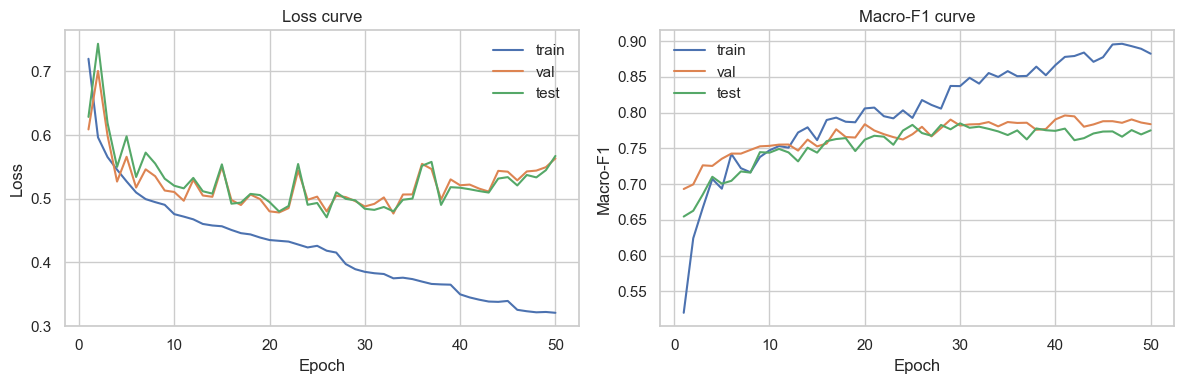

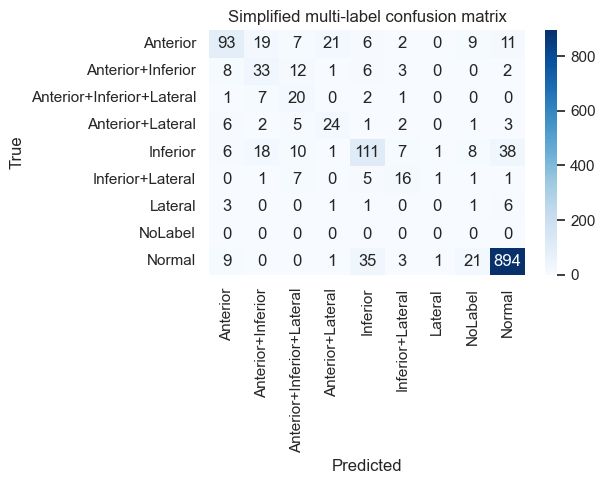

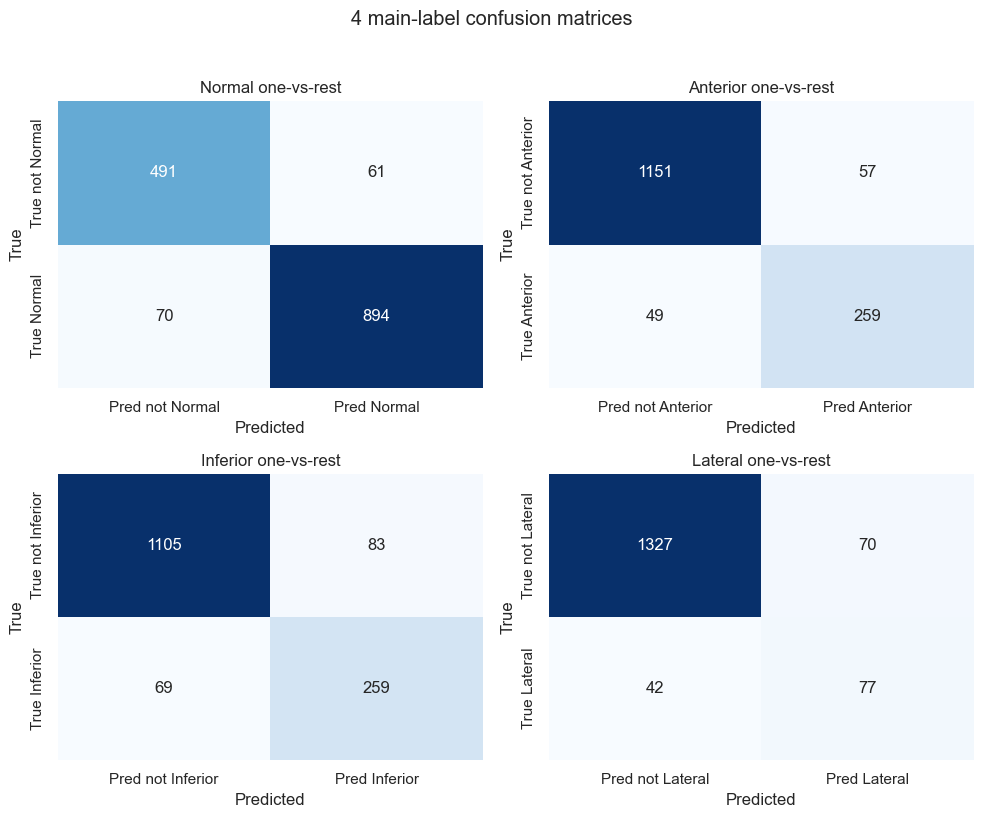

,label,TN,FP,FN,TP
0,Normal,491,61,70,894
1,Anterior,1151,57,49,259
2,Inferior,1105,83,69,259
3,Lateral,1327,70,42,77


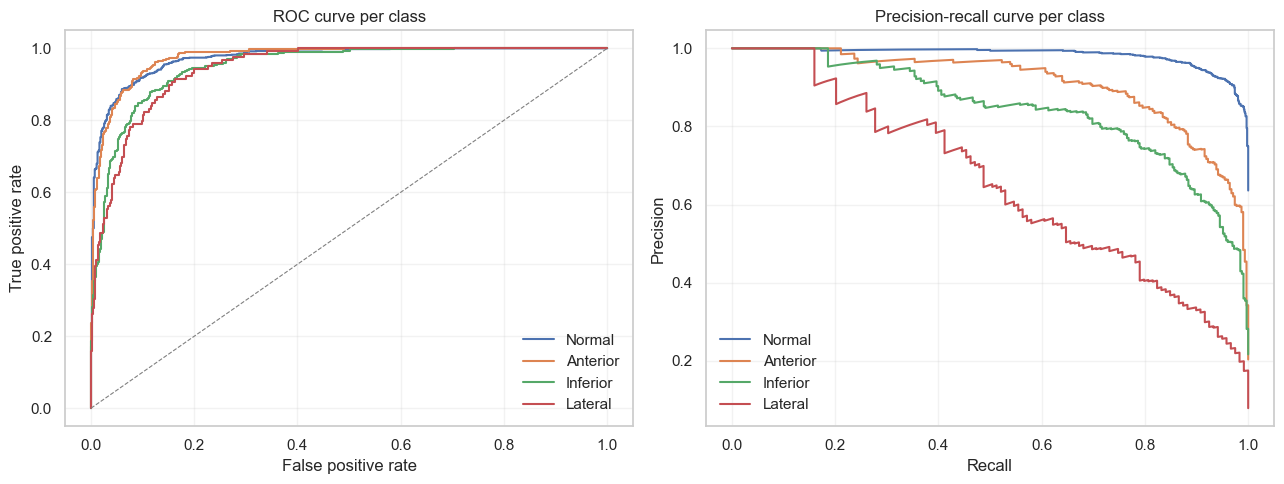

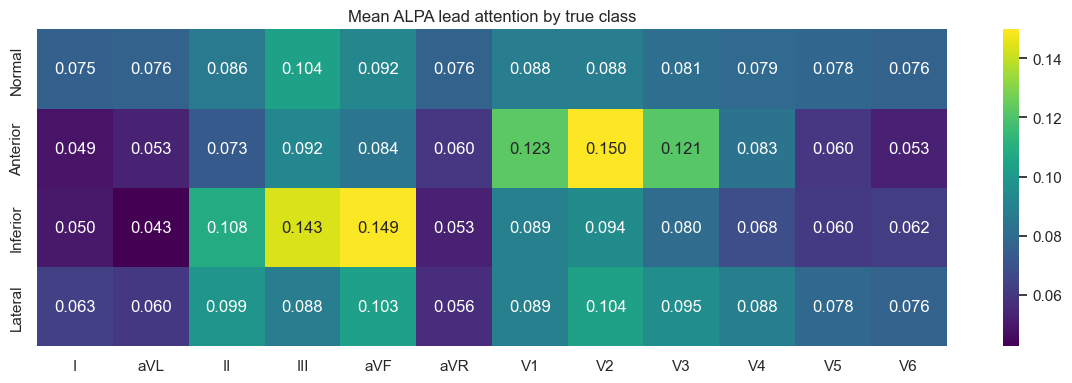

,record_id,sub_label,target_class_for_attention,correct_exact_match,top_attention_leads
0,9,normal,Normal,True,"aVL, I, V6"
1,38,normal,Normal,True,"V1, V2, aVL"
2,40,normal,Normal,True,"V2, V1, aVF"
3,57,normal,Normal,True,"II, I, aVF"
4,59,normal,Normal,True,"V1, III, aVL"
5,63,antero-septal,Anterior,False,"V2, aVR, V3"
6,162,antero-septal,Anterior,False,"V2, V3, V1"
7,240,inferior,Inferior,False,"III, aVF, V1"
8,245,normal,Normal,False,"III, aVF, II"
9,271,antero-septal,Anterior,False,"V3, II, aVF"


In [12]:
def plot_training_curves(metrics_csv, out_path):
    df = pd.read_csv(metrics_csv)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df['epoch'], df['train_loss'], label='train')
    axes[0].plot(df['epoch'], df['val_loss'], label='val')
    axes[0].plot(df['epoch'], df['test_loss'], label='test')
    axes[0].set_title('Loss curve')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend(frameon=False)
    axes[1].plot(df['epoch'], df['train_macro_f1'], label='train')
    axes[1].plot(df['epoch'], df['val_macro_f1'], label='val')
    axes[1].plot(df['epoch'], df['test_macro_f1'], label='test')
    axes[1].set_title('Macro-F1 curve')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro-F1')
    axes[1].legend(frameon=False)
    fig.tight_layout()
    fig.savefig(out_path, dpi=250, bbox_inches='tight')
    plt.show()

plot_training_curves(metrics_path, PLOT_DIR / 'training_curve.png')

true_simple = simplified_label(test_state['y_true'].astype(int))
pred_simple = simplified_label(test_pred.astype(int))
cm_labels = sorted(set(true_simple) | set(pred_simple))
cm = confusion_matrix(true_simple, pred_simple, labels=cm_labels)
plt.figure(figsize=(max(6, len(cm_labels) * 0.7), max(5, len(cm_labels) * 0.55)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.title('Simplified multi-label confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confusion_matrix.png', dpi=250, bbox_inches='tight')
plt.show()

# Multi-label one-vs-rest confusion matrix for the 4 main labels.
one_vs_rest_rows = []
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, name in enumerate(MAIN_LABELS):
    cm_binary = confusion_matrix(test_state['y_true'][:, i].astype(int), test_pred[:, i].astype(int), labels=[0, 1])
    tn, fp, fn, tp = cm_binary.ravel()
    one_vs_rest_rows.append({'label': name, 'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)})
    sns.heatmap(
        cm_binary,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'Pred not {name}', f'Pred {name}'],
        yticklabels=[f'True not {name}', f'True {name}'],
        ax=axes[i],
        cbar=False,
    )
    axes[i].set_title(f'{name} one-vs-rest')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
fig.suptitle('4 main-label confusion matrices', y=1.02)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'confusion_matrix_4_main_labels.png', dpi=250, bbox_inches='tight')
plt.show()
one_vs_rest_cm_df = pd.DataFrame(one_vs_rest_rows)
one_vs_rest_cm_df.to_csv(PLOT_DIR / 'confusion_matrix_4_main_labels.csv', index=False)
display(one_vs_rest_cm_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, name in enumerate(MAIN_LABELS):
    if len(np.unique(test_state['y_true'][:, i])) >= 2:
        fpr, tpr, _ = roc_curve(test_state['y_true'][:, i], test_prob[:, i])
        precision, recall, _ = precision_recall_curve(test_state['y_true'][:, i], test_prob[:, i])
        axes[0].plot(fpr, tpr, label=name)
        axes[1].plot(recall, precision, label=name)
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8)
axes[0].set_title('ROC curve per class')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[1].set_title('Precision-recall curve per class')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
for ax in axes:
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'roc_pr_curve.png', dpi=250, bbox_inches='tight')
plt.show()

mean_attn_by_class = []
for class_idx, name in enumerate(MAIN_LABELS):
    mask = test_state['y_true'][:, class_idx] == 1
    if mask.any():
        mean_attn_by_class.append(test_state['lead_attention'][mask, class_idx, :].mean(axis=0))
    else:
        mean_attn_by_class.append(np.zeros(len(LEAD_ORDER)))
attn_df = pd.DataFrame(mean_attn_by_class, index=MAIN_LABELS, columns=LEAD_ORDER)
plt.figure(figsize=(12, 4))
sns.heatmap(attn_df, annot=True, fmt='.3f', cmap='viridis')
plt.title('Mean ALPA lead attention by true class')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'lead_attention_heatmap.png', dpi=250, bbox_inches='tight')
plt.show()

def top_attention_examples(labels_df, state, y_prob, y_pred, n=5):
    rows = []
    y_true = state['y_true'].astype(int)
    for sample_idx in range(min(len(labels_df), len(y_true))):
        correct = bool(np.array_equal(y_true[sample_idx], y_pred[sample_idx]))
        active_classes = np.flatnonzero(y_true[sample_idx] == 1)
        class_idx = int(active_classes[0]) if len(active_classes) else int(np.argmax(y_prob[sample_idx]))
        attn = state['lead_attention'][sample_idx, class_idx]
        top = [LEAD_ORDER[i] for i in np.argsort(attn)[::-1][:3]]
        rows.append({
            'record_id': labels_df.iloc[sample_idx]['record_id'],
            'sub_label': labels_df.iloc[sample_idx]['sub_label'],
            'target_class_for_attention': MAIN_LABELS[class_idx],
            'correct_exact_match': correct,
            'top_attention_leads': ', '.join(top),
        })
    df = pd.DataFrame(rows)
    return pd.concat([df[df.correct_exact_match].head(n), df[~df.correct_exact_match].head(n)], ignore_index=True)

attention_examples = top_attention_examples(labels_test, test_state, test_prob, test_pred, n=5)
attention_examples.to_csv(PLOT_DIR / 'top_attention_examples.csv', index=False)
display(attention_examples)

## 13. Quick sanity checks for transfer learning compatibility

In [13]:
# Sanity check artifact loading and transfer freeze schemes.
backbone_payload = torch.load(TRANSFER_DIR / 'alpanet_backbone.pt', map_location='cpu')
full_payload = torch.load(TRANSFER_DIR / 'alpanet_full_model.pt', map_location='cpu')

scratch_model = ALPANet(CONFIG)
frozen_model = ALPANet(CONFIG)
frozen_model.backbone.load_state_dict(backbone_payload['backbone_state_dict'])
freeze_for_transfer(frozen_model, 'frozen_backbone')
partial_model = ALPANet(CONFIG)
partial_model.backbone.load_state_dict(backbone_payload['backbone_state_dict'])
freeze_for_transfer(partial_model, 'partial_finetune')
full_model = ALPANet(CONFIG)
full_model.load_state_dict(full_payload['model_state_dict'])
freeze_for_transfer(full_model, 'full_finetune')

sanity = pd.DataFrame([
    {'scheme': 'no_pretrain', 'trainable_params': sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)},
    {'scheme': 'frozen_backbone', 'trainable_params': sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)},
    {'scheme': 'partial_finetune', 'trainable_params': sum(p.numel() for p in partial_model.parameters() if p.requires_grad)},
    {'scheme': 'full_finetune', 'trainable_params': sum(p.numel() for p in full_model.parameters() if p.requires_grad)},
])
display(sanity)
logger.info('Transfer compatibility sanity check passed.')
print('Notebook complete. Output:', OUTPUT_DIR)

/tmp/ipykernel_47786/842726943.py:101: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.cross_lead_transformer = nn.TransformerEncoder(cross_layer, num_layers=m['cross_lead_layers'])
/tmp/ipykernel_47786/842726943.py:106: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=m['temporal_layers'])


,scheme,trainable_params
0,no_pretrain,562600
1,frozen_backbone,50055
2,partial_finetune,498440
3,full_finetune,562600


2026-06-07 19:23:22,660 | INFO | Transfer compatibility sanity check passed.


Notebook complete. Output: /home/nugee/code-program/code-thesis/hibah/myocardial-infarction-localization/outputs/pretrain_alpanet_ptbxl/20260607_190207
